In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from MODELS.xgboostModel import *
from MODELS.ngboostModel import *
from PRODUCTION.pipeline import *

In [2]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


# Backtesting Training data
train_df = pd.concat([s21,s22,s23,s24,s25])
train_df = train_df[(train_df['MIN'] >= 10)]

# Backtesting Validation data
val_df = s26
val_df = val_df[(val_df['MIN'] >= 10)]


print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")

train_df.sample(5)

/var/folders/9q/5_554qsx5z70w9d_vkmvjg0h0000gn/T/ipykernel_31025/256704780.py:10: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


Train set: 107776 samples
Val set: 4069 samples


,Unnamed: 0,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,GAMES_THIS_SEASON,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_3,AST_ROLLING_AVG_3,FGM_ROLLING_AVG_3,FGA_ROLLING_AVG_3,FG_PCT_ROLLING_AVG_3,FG3M_ROLLING_AVG_3,FG3A_ROLLING_AVG_3,FG3_PCT_ROLLING_AVG_3,FTA_ROLLING_AVG_3,FTM_ROLLING_AVG_3,FT_PCT_ROLLING_AVG_3,TOV_ROLLING_AVG_3,TS_PCT_ROLLING_AVG_3,USG_PCT_ROLLING_AVG_3,MIN_ROLLING_AVG_3,PACE_ROLLING_AVG_3,PIE_ROLLING_AVG_3,E_OFF_RATING_ROLLING_AVG_3,NET_RATING_ROLLING_AVG_3,TCHS_ROLLING_AVG_3,POSS_ROLLING_AVG_3,EFG_PCT_ROLLING_AVG_3,percentagePointsPaint_ROLLING_AVG_3,percentagePointsMidrange2pt_ROLLING_AVG_3,percentagePoints3pt_ROLLING_AVG_3,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_20,AST_ROLLING_AVG_2

In [3]:
features = [
    # ===== CORE CONTEXT =====
    'HOME_GAME',
    'STARTING',
    'PLAYER_IS_TEAM_STAR',
    'STAR_SAT_OUT',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'OPP_USUAL_STARTERS_AVAILABLE',
    'OPP_STAR_OUT', #new
    'GAMES_PLAYED_TO_DATE',

    # ===== ROLLING AVERAGES =====
    'PTS_ROLLING_AVG_3', #new
    'PTS_ROLLING_AVG_5', 
    'PTS_ROLLING_AVG_10',
    'PTS_ROLLING_AVG_20', 
    'MIN_ROLLING_AVG_3', #new
    'MIN_ROLLING_AVG_5', 
    'MIN_ROLLING_AVG_10',
    'MIN_ROLLING_AVG_20', 
    'USG_PCT_ROLLING_AVG_3', #new
    'USG_PCT_ROLLING_AVG_5', 
    'USG_PCT_ROLLING_AVG_10',
    'USG_PCT_ROLLING_AVG_20',
    'TS_PCT_ROLLING_AVG_10',
    'TS_PCT_ROLLING_AVG_20', 
    'FGA_ROLLING_AVG_3', #new
    'FGA_ROLLING_AVG_5', 
    'FGA_ROLLING_AVG_10', 
    'FGA_ROLLING_AVG_20', 
    'FGM_ROLLING_AVG_10', #new
    'FGM_ROLLING_AVG_20', #new
    'FG_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_20', 
    'FG3M_ROLLING_AVG_3', #new
    'FG3A_ROLLING_AVG_5', 
    'FG3A_ROLLING_AVG_10', 
    'FG3A_ROLLING_AVG_20', 
    'FG3M_ROLLING_AVG_10', #new
    'FG3M_ROLLING_AVG_20', #new
    'FG3_PCT_ROLLING_AVG_10', 
    'FG3_PCT_ROLLING_AVG_20', 
    'FTA_ROLLING_AVG_5', 
    'FTA_ROLLING_AVG_10', 
    'FTA_ROLLING_AVG_20',
    'FTM_ROLLING_AVG_5', #new
    'FTM_ROLLING_AVG_10', #new
    'FTM_ROLLING_AVG_20', #new
    'FT_PCT_ROLLING_AVG_10', 
    'FT_PCT_ROLLING_AVG_20', 
    'E_OFF_RATING_ROLLING_AVG_5',
    'E_OFF_RATING_ROLLING_AVG_10',
    'E_OFF_RATING_ROLLING_AVG_20', 
    'NET_RATING_ROLLING_AVG_5', 
    'NET_RATING_ROLLING_AVG_10',
    'NET_RATING_ROLLING_AVG_20', 
    'PIE_ROLLING_AVG_20', #new

    # ===== LAG FEATURES =====
    'MIN_LAG_1',
    'PTS_LAG_1',
    'FGA_LAG_1',
    'USG_PCT_LAG_1',
    'POSS_LAG_1', #new
    'TS_PCT_LAG_1', #new
    'TCHS_LAG_1', #new
    
    # ===== VOLATILITY =====
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'MIN_VOLATILITY_20_TO_DATE', 
    'PTS_VOLATILITY_5_TO_DATE',
    'PTS_VOLATILITY_10_TO_DATE', 
    'PTS_VOLATILITY_20_TO_DATE', 
    'FGA_VOLATILITY_5_TO_DATE',
    'FGA_VOLATILITY_10_TO_DATE',
    'FGA_VOLATILITY_20_TO_DATE',
    'USG_PCT_CV_5_TO_DATE',
    'USG_PCT_CV_10_TO_DATE', 
    'USG_PCT_CV_20_TO_DATE', 
    'TS_PCT_CV_10_TO_DATE',
    'TS_PCT_CV_20_TO_DATE', 
    'FG3A_VOLATILITY_5_TO_DATE',
    'FG3A_VOLATILITY_10_TO_DATE', 
    'FG3A_VOLATILITY_20_TO_DATE',
    'FG3_PCT_CV_10_TO_DATE',
    'FG3_PCT_CV_20_TO_DATE', 
    'FTA_VOLATILITY_5_TO_DATE',
    'FTA_VOLATILITY_10_TO_DATE', 
    'FTA_VOLATILITY_20_TO_DATE', 
    'FT_PCT_CV_10_TO_DATE',
    'FT_PCT_CV_20_TO_DATE', 
    'TOV_VOLATILITY_10_TO_DATE',
    'PACE_VOLATILITY_5_TO_DATE',
    'PACE_VOLATILITY_10_TO_DATE',
    'E_OFF_RATING_VOLATILITY_5_TO_DATE',
    'E_OFF_RATING_VOLATILITY_10_TO_DATE',
    'NET_RATING_VOLATILITY_5_TO_DATE',
    'NET_RATING_VOLATILITY_10_TO_DATE',
    'TCHS_ROLLING_AVG_5', 
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_5', 
    'TOV_ROLLING_AVG_10',

    # ===== MIN/MAX (Useful extremes) =====
    'MIN_MAX_LAST_10', 
    'MIN_MIN_LAST_10',
    'PTS_MIN_LAST_10',
    'PTS_MAX_LAST_10', #new
    'PTS_MIN_LAST_20', #new
    'PTS_MAX_LAST_20', #new
    'USG_PCT_MAX_LAST_10',
    'USG_PCT_MIN_LAST_10',
    'TS_PCT_MAX_LAST_10', #new
    'TS_PCT_MIN_LAST_10', #new
    'PTS_RANGE_10', 
    'USG_PCT_RANGE_10', 
    'TS_PCT_RANGE_10', 
    
    # ==== Short vs long term divergences =====
    'PTS_5G_VS_20G_RATIO', 
    'MIN_5G_VS_20G_RATIO', 
    'USG_PCT_5G_VS_20G_RATIO', 
    
    # === Consistency metrics =====
    'PTS_CONSISTENCY', 
    'MIN_CONSISTENCY',
    'USG_PCT_CONSISTENCY', 
    
    # === Variance stability metrics =====
    'VARIANCE_STABILITY',
    'MIN_VARIANCE_STABILITY', 
    'USG_PCT_VARIANCE_STABILITY', 
    'TS_PCT_VARIANCE_STABILITY', 
    
    # ===== TRENDS =====
    'PTS_TREND_LAST_5',
    'MIN_TREND_LAST_5',
    'PTS_TREND_LAST_10',
    'MIN_TREND_LAST_10',
    
    # ===== INTERACTIONS (Keep - your best features) =====
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'PTS_PER_MIN_X_USG',
    'USAGE_X_EFFICIENCY',
    'USAGE_X_MINUTES', #new
    'PTS_PER_POSSESSION',
    'B2B_X_MIN_LAST_5', #new
    'USG_PCT_X_STAR_SAT_OUT', #new
    'PTS_PER_36', #new
    
    # # ===== SHOT PROFILE =====
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    # '3PA_RATE',
    # 'PLAYER_FG3A_SHARE',
    # 'PTS_PER_SHOT', 
    
    # ===== STAR DYNAMICS =====
    'PTS_DELTA_STAR_OUT',
    'USG_PCT_DELTA_STAR_OUT',
    'MIN_DELTA_STAR_OUT', 
    'FGA_DELTA_STAR_OUT', 
    'TS_PCT_DELTA_STAR_OUT', #new
    'GAMES_WITH_STAR', #new
    
    # ===== STREAKS & TIERS =====
    'IS_LOW_SCORER',
    'IS_MEDIUM_SCORER',
    'IS_HIGH_SCORER', 
    
    # ===== TEAM CONTEXT =====
    'TEAM_PTS_ROLLING_AVG_3', 
    'TEAM_AST_ROLLING_AVG_3', #new
    'TEAM_OFF_RATING_ROLLING_AVG_3', 
    'TEAM_PACE_ROLLING_AVG_3', #new
    'TEAM_DEF_RATING_ROLLING_AVG_3',
    
    # ===== OPPONENT =====
    'OPP_TEAM_DEF_RATING_ROLLING_AVG_5', #new
    'OPP_TEAM_PACE_ROLLING_AVG_5', #new
    'OPP_TOV_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE', #new
    'OPP_STL_AVG_TO_DATE', #new
    'OPP_GUARD_DEF_RATING',
    'OPP_FORWARD_DEF_RATING',
    'OPP_CENTER_DEF_RATING',
    
    # ===== MATCHUP INTERACTIONS =====
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'PLAYER_X_MATCHUP_CENTER_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    
    # ===== GAME CONTEXT =====
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    'PACE_DIFFERENTIAL',
    
    # ===== HOME/AWAY & MATCHUP =====
    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'PLAYER_HOME_TS_PCT_DELTA', #new
    'MATCHUP_PTS_DELTA', #new
    'MATCHUP_MIN_DELTA', #new
    'MATCHUP_USG_PCT_DELTA', #new
    'MATCHUP_TS_PCT_DELTA', #new
]
print(f"Enhanced features: {len(features)}")

Enhanced features: 177


In [4]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [5]:
# from MODELS.xgboostModel import *

# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=100,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

# XGBOOST MODEL

### Remove correlated features

In [6]:
# from MODELS.xgboostModel import *
# corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, features, threshold=0.95)

REMOVED: MIN_LAG_1                      (corr with POSS_LAG_1: 0.988)
REMOVED: PTS_PER_36                     (corr with PTS_ROLLING_AVG_20: 0.987)
REMOVED: FGM_ROLLING_AVG_20             (corr with PTS_ROLLING_AVG_20: 0.985)
REMOVED: FGA_ROLLING_AVG_10             (corr with FGA_ROLLING_AVG_20: 0.985)
REMOVED: FGM_ROLLING_AVG_10             (corr with PTS_ROLLING_AVG_10: 0.983)
REMOVED: FG3A_ROLLING_AVG_10            (corr with FG3A_ROLLING_AVG_20: 0.982)
REMOVED: FTA_ROLLING_AVG_20             (corr with FTM_ROLLING_AVG_20: 0.981)
REMOVED: PTS_ROLLING_AVG_10             (corr with PTS_ROLLING_AVG_20: 0.980)
REMOVED: FTA_ROLLING_AVG_10             (corr with FTM_ROLLING_AVG_10: 0.980)
REMOVED: TCHS_ROLLING_AVG_5             (corr with TCHS_ROLLING_AVG_10: 0.976)
REMOVED: FTA_ROLLING_AVG_5              (corr with FTM_ROLLING_AVG_5: 0.976)
REMOVED: USG_PCT_ROLLING_AVG_10         (corr with USG_PCT_ROLLING_AVG_20: 0.975)
REMOVED: MIN_ROLLING_AVG_10             (corr with MIN_ROLLING_AVG_

### NGBOOST MODEL

SPLIT NGBOOST

In [4]:

mean_model, variance_model, cal_factor = fit_ngboost_split(
train_df,
val_df,
features,
target_col='PTS',
distribution=Normal,
player_col='PLAYER_ID',
recent_n=20,
recent_weight=2.0,
variance_recent_weight=1.0,
variance_lr=0.03,  
variance_max_depth=7,  
variance_n_estimators=1000,
variance_calibration_factor=3.97)


Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


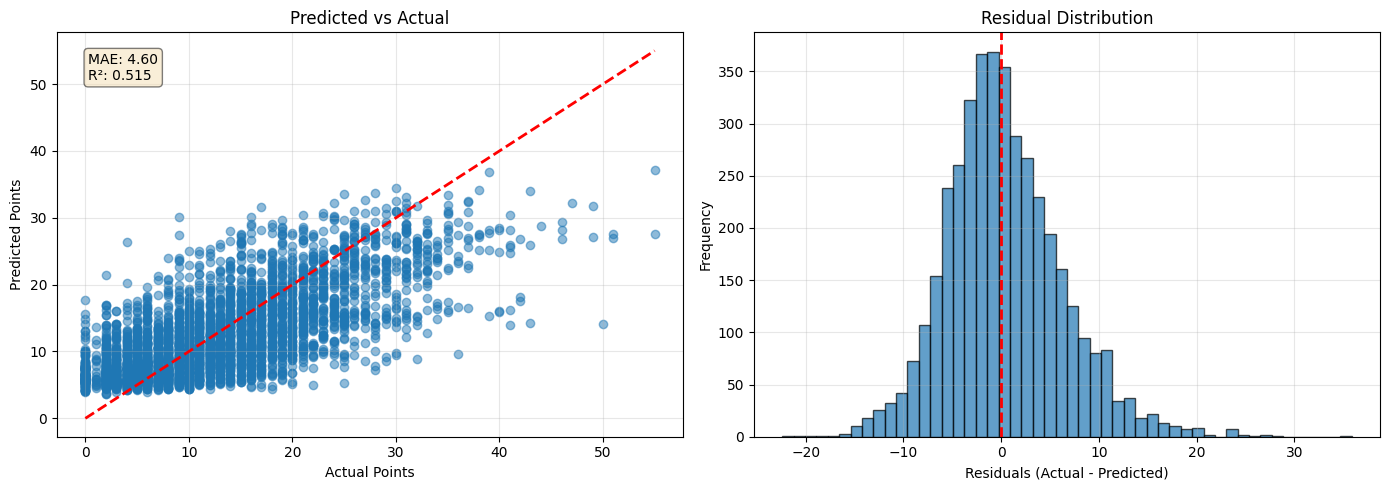

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

preds_dist = mean_model.pred_dist(val_df[features])
y_pred_mean = preds_dist.loc
y_pred_std = preds_dist.scale
y_true = val_df['PTS'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_true, y_pred_mean, alpha=0.5)
axes[0].plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

mae = mean_absolute_error(y_true, y_pred_mean)
r2 = r2_score(y_true, y_pred_mean)
axes[0].text(0.05, 0.95, f'MAE: {mae:.2f}\nR²: {r2:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

residuals = y_true - y_pred_mean
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
mean_importance_raw = mean_model.feature_importances_  
var_importance_raw = variance_model.feature_importances_    

# Average across the 2 distributions
mean_importance = mean_importance_raw.mean(axis=0)  
var_importance = var_importance_raw.mean(axis=0)    

# NOW create the DataFrame
feature_importance_df = pd.DataFrame({
    'feature': features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('mean_model', ascending=False)

# Display top features
print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'mean_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)
                                    feature  mean_model
                         FGA_ROLLING_AVG_20    0.037711
                     TEAM_PTS_ROLLING_AVG_3    0.035473
                         FGA_ROLLING_AVG_10    0.031746
                         PTS_ROLLING_AVG_20    0.031209
                            USAGE_X_MINUTES    0.030423
                          FGA_ROLLING_AVG_5    0.027326
                          FGA_ROLLING_AVG_3    0.026303
                       OPP_GUARD_DEF_RATING    0.024993
                          PTS_PER_MIN_X_USG    0.024486
                     USG_PCT_X_STAR_SAT_OUT    0.024427
                                   STARTING    0.022723
              TEAM_DEF_RATING_ROLLING_AVG_3    0.019745
                   USUAL_STARTERS_AVAILABLE    0.019560
                         PTS_DELTA_STAR_OUT    0.018536
                             IS_HIGH_SCORER    0.015900
                     TEAM_AST_ROLLING_AVG_3    0.015

In [7]:
feature_importance_df = pd.DataFrame({
    'feature': features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('var_model', ascending=False)


print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'var_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)
                         feature  var_model
                   IS_LOW_SCORER   0.027778
              FGA_ROLLING_AVG_20   0.027648
              FGA_ROLLING_AVG_10   0.021800
               PACE_DIFFERENTIAL   0.013411
                   EXPECTED_PACE   0.012755
          TEAM_PTS_ROLLING_AVG_3   0.012615
             OPP_TOV_AVG_TO_DATE   0.012523
         TEAM_PACE_ROLLING_AVG_3   0.012355
   TEAM_DEF_RATING_ROLLING_AVG_3   0.011822
          TEAM_OFF_MINUS_OPP_DEF   0.011796
            OPP_GUARD_DEF_RATING   0.011731
                 USAGE_X_MINUTES   0.011629
        MIN_VOLATILITY_5_TO_DATE   0.011407
     OPP_TEAM_PACE_ROLLING_AVG_5   0.010349
            GAMES_PLAYED_TO_DATE   0.010173
          OPP_FORWARD_DEF_RATING   0.009740
NET_RATING_VOLATILITY_10_TO_DATE   0.009613
              MIN_DELTA_STAR_OUT   0.009607
             OPP_STL_AVG_TO_DATE   0.009250
               PTS_PER_MIN_X_USG   0.009247


In [8]:
# ISOTONIC REGRESSION CALIBRATION
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error

# Get predictions on validation set BEFORE calibration
mu_before_calibration, variance = predict_mean_variance_split(
    mean_model, variance_model, val_df, features, cal_factor
)
y_true_val = val_df['PTS'].values

print("="*80)
print("CALIBRATION: Training Isotonic Regression")
print("="*80)

# Train isotonic regression on validation set predictions
# This will map raw predictions to calibrated predictions
iso_reg = IsotonicRegression(out_of_bounds='clip', increasing=True)
iso_reg.fit(mu_before_calibration, y_true_val)

# Get calibrated predictions
mu_calibrated = iso_reg.predict(mu_before_calibration)

# Compare MAE before and after calibration
mae_before = mean_absolute_error(y_true_val, mu_before_calibration)
mae_after = mean_absolute_error(y_true_val, mu_calibrated)

print(f"\nMAE Before Calibration: {mae_before:.3f}")
print(f"MAE After Calibration: {mae_after:.3f}")
print(f"Improvement: {mae_before - mae_after:.3f} ({((mae_before - mae_after) / mae_before * 100):.2f}%)")

# Check calibration curve
print("\n" + "="*80)
print("CALIBRATION CURVE ANALYSIS")
print("="*80)

# Binned analysis to show calibration improvement
bins = np.linspace(0, 50, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2

for i in range(len(bins) - 1):
    mask = (y_true_val >= bins[i]) & (y_true_val < bins[i+1])
    if mask.sum() > 0:
        avg_true = y_true_val[mask].mean()
        avg_pred_before = mu_before_calibration[mask].mean()
        avg_pred_after = mu_calibrated[mask].mean()
        print(f"Bin [{bins[i]:.1f}, {bins[i+1]:.1f}): "
              f"True={avg_true:.2f}, "
              f"Before={avg_pred_before:.2f} (err={abs(avg_true-avg_pred_before):.2f}), "
              f"After={avg_pred_after:.2f} (err={abs(avg_true-avg_pred_after):.2f}), "
              f"N={mask.sum()}")



CALIBRATION: Training Isotonic Regression

MAE Before Calibration: 4.604
MAE After Calibration: 4.553
Improvement: 0.051 (1.11%)

CALIBRATION CURVE ANALYSIS
Bin [0.0, 5.0): True=2.34, Before=7.50 (err=5.16), After=7.60 (err=5.26), N=741
Bin [5.0, 10.0): True=7.02, Before=9.06 (err=2.05), After=9.27 (err=2.25), N=1042
Bin [10.0, 15.0): True=11.91, Before=11.45 (err=0.46), After=11.80 (err=0.10), N=879
Bin [15.0, 20.0): True=16.84, Before=14.48 (err=2.37), After=14.77 (err=2.07), N=627
Bin [20.0, 25.0): True=21.71, Before=17.22 (err=4.49), After=17.50 (err=4.21), N=369
Bin [25.0, 30.0): True=26.65, Before=20.47 (err=6.18), After=20.75 (err=5.90), N=212
Bin [30.0, 35.0): True=31.65, Before=22.92 (err=8.73), After=23.13 (err=8.52), N=126
Bin [35.0, 40.0): True=36.44, Before=25.90 (err=10.54), After=26.32 (err=10.12), N=43
Bin [40.0, 45.0): True=41.37, Before=23.46 (err=17.90), After=23.83 (err=17.54), N=19
Bin [45.0, 50.0): True=47.17, Before=29.35 (err=17.82), After=29.98 (err=17.18), N=6

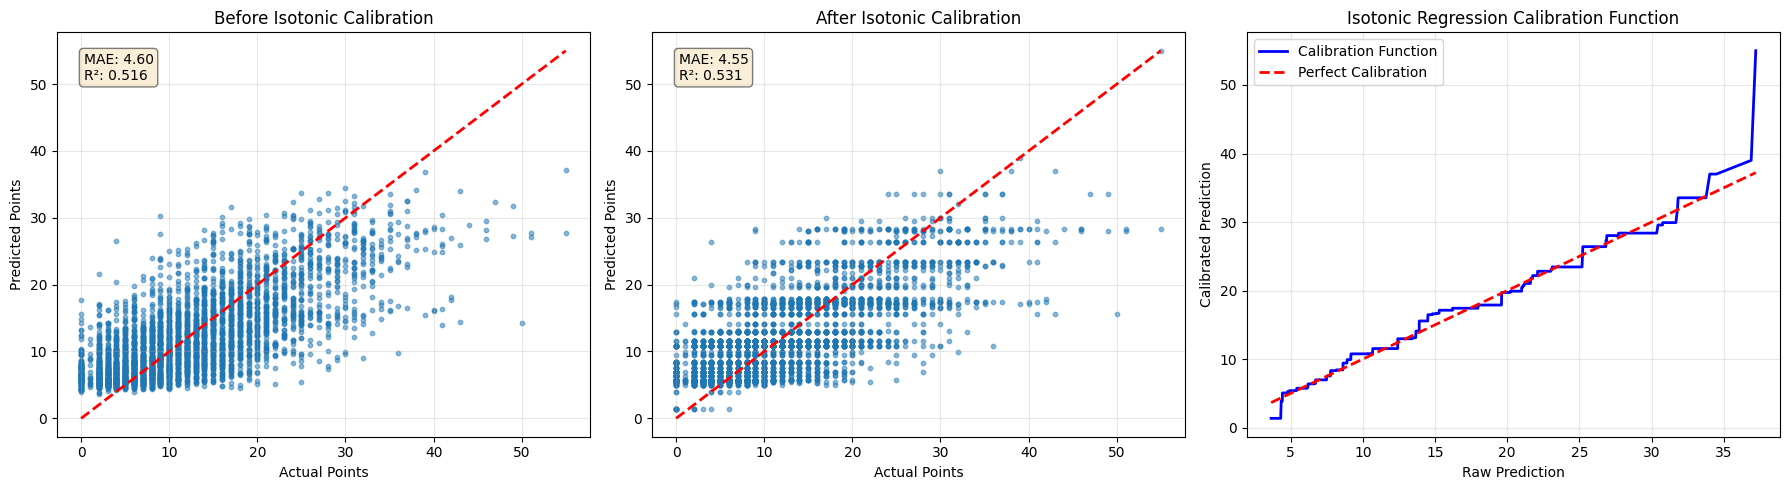


R² Before: 0.5156
R² After: 0.5307
R² Improvement: 0.0151


In [9]:
# Visualize calibration improvement
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Before Calibration
axes[0].scatter(y_true_val, mu_before_calibration, alpha=0.5, s=10)
axes[0].plot([y_true_val.min(), y_true_val.max()], 
             [y_true_val.min(), y_true_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Before Isotonic Calibration')
axes[0].grid(True, alpha=0.3)
r2_before = r2_score(y_true_val, mu_before_calibration)
axes[0].text(0.05, 0.95, f'MAE: {mae_before:.2f}\nR²: {r2_before:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: After Calibration
axes[1].scatter(y_true_val, mu_calibrated, alpha=0.5, s=10)
axes[1].plot([y_true_val.min(), y_true_val.max()], 
             [y_true_val.min(), y_true_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Points')
axes[1].set_ylabel('Predicted Points')
axes[1].set_title('After Isotonic Calibration')
axes[1].grid(True, alpha=0.3)
r2_after = r2_score(y_true_val, mu_calibrated)
axes[1].text(0.05, 0.95, f'MAE: {mae_after:.2f}\nR²: {r2_after:.3f}', 
             transform=axes[1].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Calibration Function
sorted_indices = np.argsort(mu_before_calibration)
axes[2].plot(mu_before_calibration[sorted_indices], 
             mu_calibrated[sorted_indices], 
             'b-', lw=2, label='Calibration Function')
axes[2].plot([mu_before_calibration.min(), mu_before_calibration.max()], 
             [mu_before_calibration.min(), mu_before_calibration.max()], 
             'r--', lw=2, label='Perfect Calibration')
axes[2].set_xlabel('Raw Prediction')
axes[2].set_ylabel('Calibrated Prediction')
axes[2].set_title('Isotonic Regression Calibration Function')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nR² Before: {r2_before:.4f}")
print(f"R² After: {r2_after:.4f}")
print(f"R² Improvement: {r2_after - r2_before:.4f}")


In [10]:
# CALIBRATION SUMMARY TABLE
from IPython.display import display, HTML

# Calculate key metrics
from sklearn.metrics import mean_squared_error

rmse_before = np.sqrt(mean_squared_error(y_true_val, mu_before_calibration))
rmse_after = np.sqrt(mean_squared_error(y_true_val, mu_calibrated))

# Calculate prediction intervals
residuals_before = y_true_val - mu_before_calibration
residuals_after = y_true_val - mu_calibrated

# Create comparison dataframe
comparison_data = {
    'Metric': [
        'Mean Absolute Error',
        'Root Mean Squared Error',
        'R² Score',
        'Mean Residual (Bias)',
        'Std Dev of Residuals',
        'Max Absolute Error',
        'Median Absolute Error',
        'Improvement %'
    ],
    'Before Calibration': [
        f"{mae_before:.3f}",
        f"{rmse_before:.3f}",
        f"{r2_before:.4f}",
        f"{residuals_before.mean():.3f}",
        f"{residuals_before.std():.3f}",
        f"{np.abs(residuals_before).max():.3f}",
        f"{np.median(np.abs(residuals_before)):.3f}",
        "—"
    ],
    'After Calibration': [
        f"{mae_after:.3f}",
        f"{rmse_after:.3f}",
        f"{r2_after:.4f}",
        f"{residuals_after.mean():.3f}",
        f"{residuals_after.std():.3f}",
        f"{np.abs(residuals_after).max():.3f}",
        f"{np.median(np.abs(residuals_after)):.3f}",
        "—"
    ],
    'Improvement': [
        f"{mae_before - mae_after:.3f}",
        f"{rmse_before - rmse_after:.3f}",
        f"{r2_after - r2_before:.4f}",
        f"{abs(residuals_before.mean()) - abs(residuals_after.mean()):.3f}",
        f"{residuals_before.std() - residuals_after.std():.3f}",
        f"{np.abs(residuals_before).max() - np.abs(residuals_after).max():.3f}",
        f"{np.median(np.abs(residuals_before)) - np.median(np.abs(residuals_after)):.3f}",
        f"{((mae_before - mae_after) / mae_before * 100):.2f}%"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("="*80)
print("ISOTONIC CALIBRATION IMPACT SUMMARY")
print("="*80)
print()
display(comparison_df)

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
print(f"✓ MAE improved by {((mae_before - mae_after) / mae_before * 100):.2f}%")
print(f"✓ R² improved by {(r2_after - r2_before):.4f}")
print(f"✓ Bias reduced from {abs(residuals_before.mean()):.3f} to {abs(residuals_after.mean()):.3f}")
print(f"✓ Residual spread reduced by {(residuals_before.std() - residuals_after.std()):.3f}")
print("\n📊 Calibration function successfully maps predictions to better match outcomes")


ISOTONIC CALIBRATION IMPACT SUMMARY



,Metric,Before Calibration,After Calibration,Improvement
0,Mean Absolute Error,4.604,4.553,0.051
1,Root Mean Squared Error,6.014,5.919,0.095
2,R² Score,0.5156,0.5307,0.0151
3,Mean Residual (Bias),0.252,0.000,0.252
4,Std Dev of Residuals,6.008,5.919,0.089
5,Max Absolute Error,35.767,34.435,1.332
6,Median Absolute Error,3.679,3.577,0.102
7,Improvement %,—,—,1.11%



KEY INSIGHTS
✓ MAE improved by 1.11%
✓ R² improved by 0.0151
✓ Bias reduced from 0.252 to 0.000
✓ Residual spread reduced by 0.089

📊 Calibration function successfully maps predictions to better match outcomes


In [11]:
validate_production_model(mean_model, variance_model, val_df, features, 'PTS', cal_factor)

=== CALIBRATION CHECK ===
Standardized residuals mean: 0.042 (should be ~0)
Standardized residuals std: 1.011 (should be ~1)
Q25: Predicted=8.3, Actual=6.0
Q50: Predicted=12.2, Actual=11.0
Q75: Predicted=16.1, Actual=17.0

MAE: 4.60
90% CI: Coverage=90.73%, Expected=90.00%
95% CI: Coverage=94.99%, Expected=95.00%
99% CI: Coverage=98.43%, Expected=99.00%


array([-0.61491312,  0.99307671,  1.68535077, ...,  1.12949858,
       -0.05544057, -1.36862228], shape=(4069,))

In [12]:
import joblib

# Save NGBoost split models (mean, variance, calibration factor, and isotonic regression calibrator)
joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_PRODUCTION.pkl')
joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_PRODUCTION.pkl')
joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTION.pkl')
joblib.dump(iso_reg, 'SAVED_MODELS/NGBOOST_PTS_ISOTONIC_CALIBRATOR_PRODUCTION.pkl')

joblib.dump(features, 'SAVED_MODELS/feature_list.pkl')

print("="*80)
print("Models saved successfully!")
print("="*80)
print("✓ Mean model")
print("✓ Variance model")
print("✓ Calibration factor")
print("✓ Isotonic regression calibrator")
print("✓ Feature list")

Models saved successfully!
✓ Mean model
✓ Variance model
✓ Calibration factor
✓ Isotonic regression calibrator
✓ Feature list


In [13]:
# import joblib

# joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_25v1.pkl')
# joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_25v1.pkl')
# joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_25v1.pkl')

# joblib.dump(features, 'SAVED_MODELS/feature_listv1.pkl')